In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

### Load Data

In [2]:
calendar = pd.read_csv("../data/calendar.csv")
prices = pd.read_csv("../data/sell_prices.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")

## Dataset Overview

Before starting the analysis, we inspect the size and structure
of the datasets to understand the available information.

In [3]:
print("Calendar Shape:", calendar.shape)
print("Prices Shape:", prices.shape)
print("Sales Shape:", sales.shape)

Calendar Shape: (1969, 14)
Prices Shape: (6841121, 4)
Sales Shape: (30490, 1919)


In [4]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [5]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [6]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


## Missing Value Analysis

This section identifies missing values across all datasets and
evaluates whether data cleaning is required.

In [7]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [8]:
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [9]:
sales.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

### Observation

Missing values are present only in event-related columns within
the calendar dataset.

These missing values are expected because events do not occur
every day and therefore do not represent data quality issues.

In [10]:
state_counts = sales['state_id'].value_counts()

state_counts

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

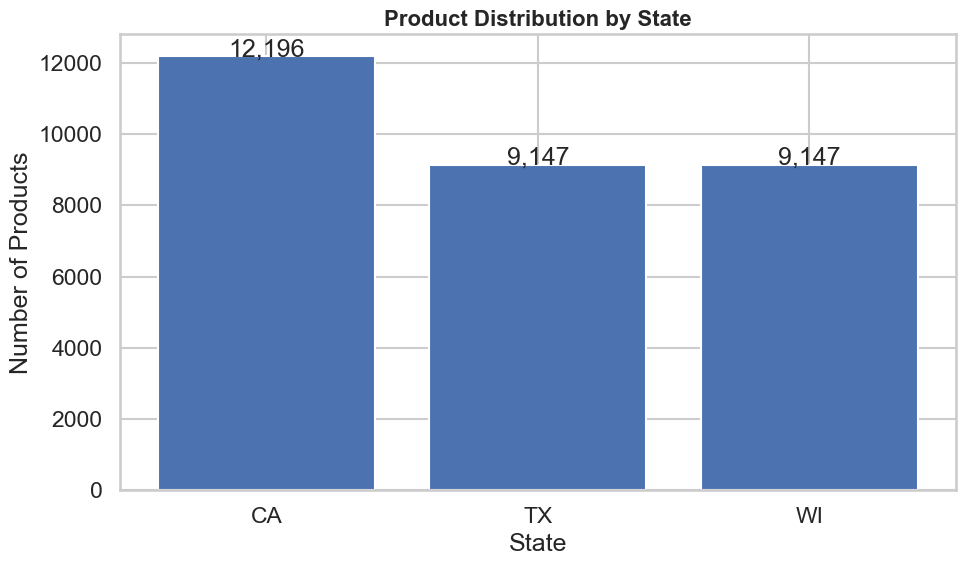

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    state_counts.index,
    state_counts.values
)

ax.set_title("Product Distribution by State")
ax.set_xlabel("State")
ax.set_ylabel("Number of Products")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "../screenshots/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight

California contains the largest number of product-store
combinations, indicating broader product coverage compared
to Texas and Wisconsin.

## Category Analysis

Evaluate product distribution across major categories.

In [12]:
category_counts = sales['cat_id'].value_counts()

category_counts

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

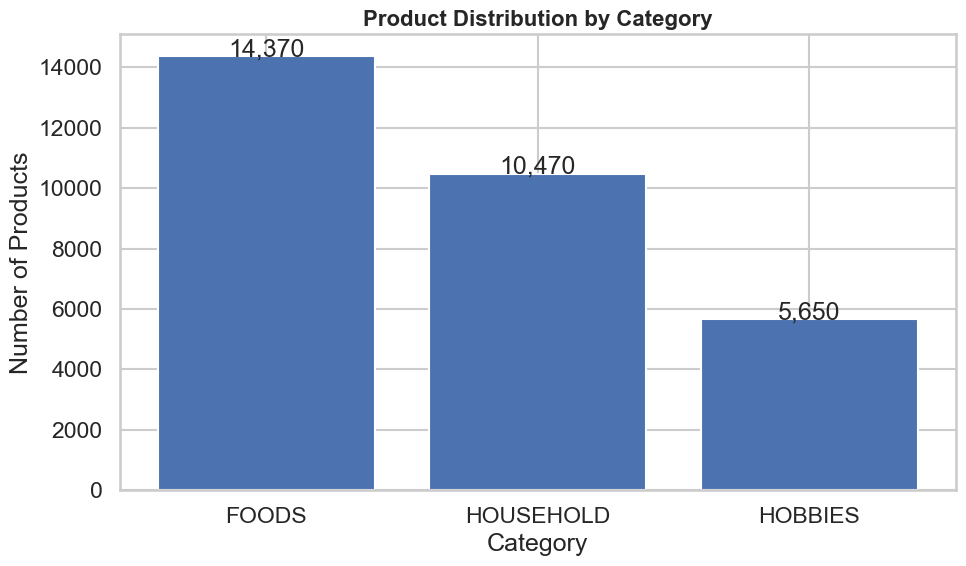

In [13]:
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    category_counts.index,
    category_counts.values
)

ax.set_title("Product Distribution by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Products")

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "../screenshots/category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight

FOODS represents the largest category within the dataset,
suggesting it is likely to drive a significant share of demand.

## Department Analysis

In [14]:
top_dept = sales['dept_id'].value_counts().head(10)

top_dept

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

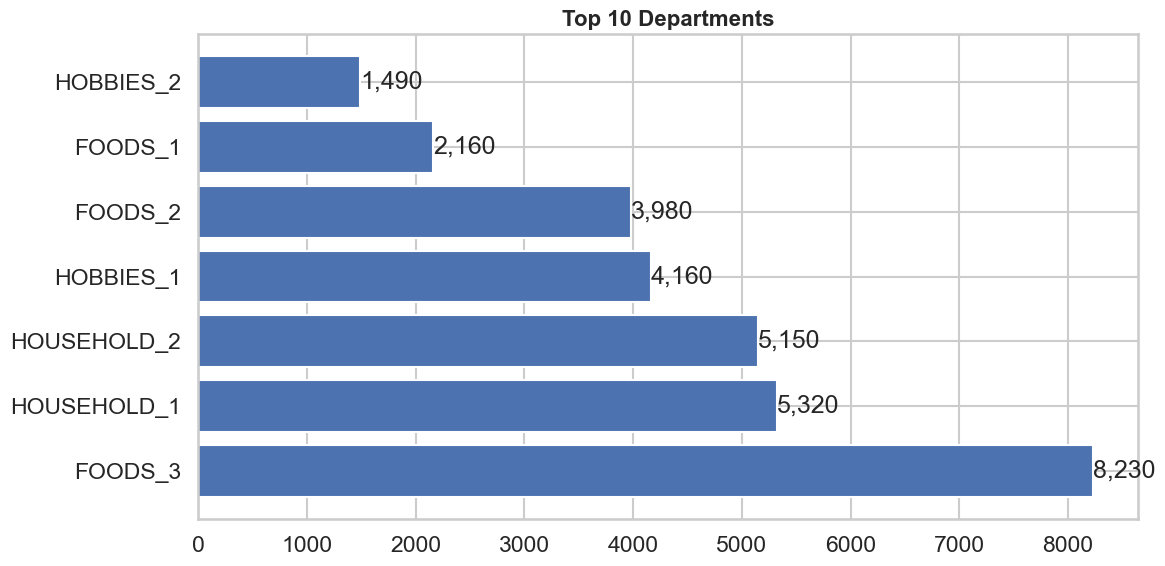

In [15]:
fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    top_dept.index,
    top_dept.values
)

ax.set_title("Top 10 Departments")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width:,}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    "../screenshots/top_departments.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Product-Level Demand Analysis

Create a total sales metric for each product across the
entire historical period.

In [16]:
sales['total_sales'] = sales.iloc[:,6:].sum(axis=1)

In [17]:
sales[['item_id','total_sales']].head()

,item_id,total_sales
0,HOBBIES_1_001,600
1,HOBBIES_1_002,493
2,HOBBIES_1_003,288
3,HOBBIES_1_004,3288
4,HOBBIES_1_005,1849


## Top Selling Products

In [18]:
top_products = (
    sales[['item_id','total_sales']]
    .sort_values(
        'total_sales',
        ascending=False
    )
    .head(10)
)

top_products

,item_id,total_sales
8412,FOODS_3_090,250502
18055,FOODS_3_586,192835
21104,FOODS_3_586,150122
8908,FOODS_3_586,134386
2314,FOODS_3_090,127203
29755,FOODS_3_090,121434
17559,FOODS_3_090,119496
20608,FOODS_3_090,114854
17721,FOODS_3_252,114153
15006,FOODS_3_586,112454


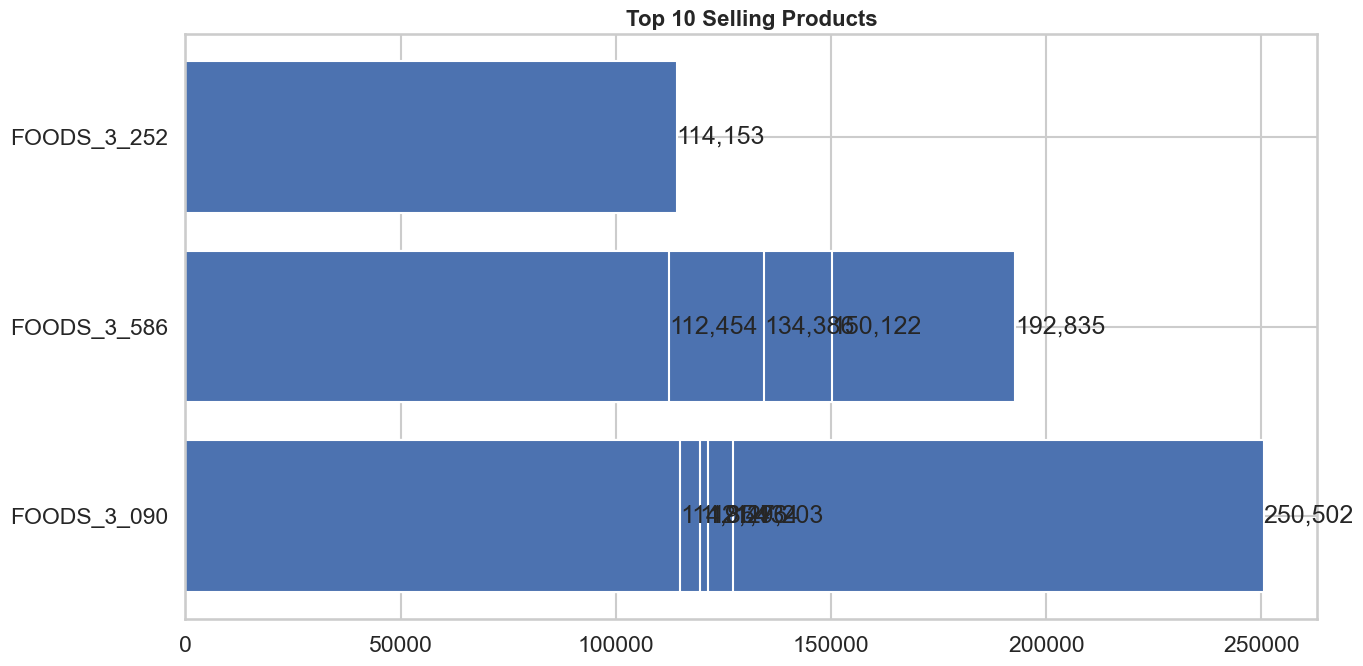

In [19]:
fig, ax = plt.subplots(figsize=(14,7))

bars = ax.barh(
    top_products['item_id'],
    top_products['total_sales']
)

ax.set_title("Top 10 Selling Products")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    "../screenshots/top_products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Sales by Category

In [20]:
category_sales = (
    sales.groupby('cat_id')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

cat_id
FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
Name: total_sales, dtype: int64

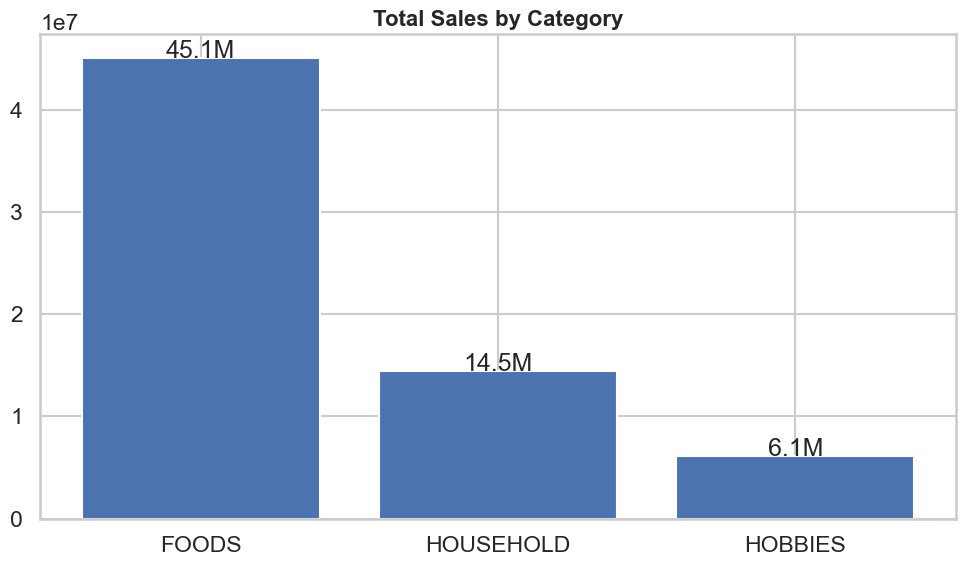

In [21]:
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    category_sales.index,
    category_sales.values
)

ax.set_title("Total Sales by Category")

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "../screenshots/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Sales by State

In [22]:
state_sales = (
    sales.groupby('state_id')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

state_sales

state_id
CA    28675547
TX    18899006
WI    18120856
Name: total_sales, dtype: int64

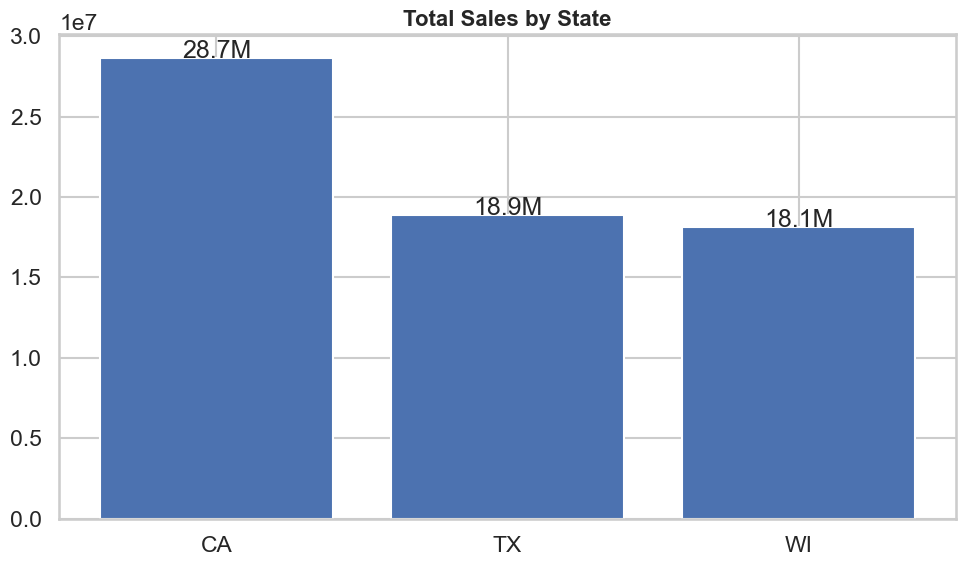

In [23]:
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    state_sales.index,
    state_sales.values
)

ax.set_title("Total Sales by State")

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "../screenshots/sales_by_state.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

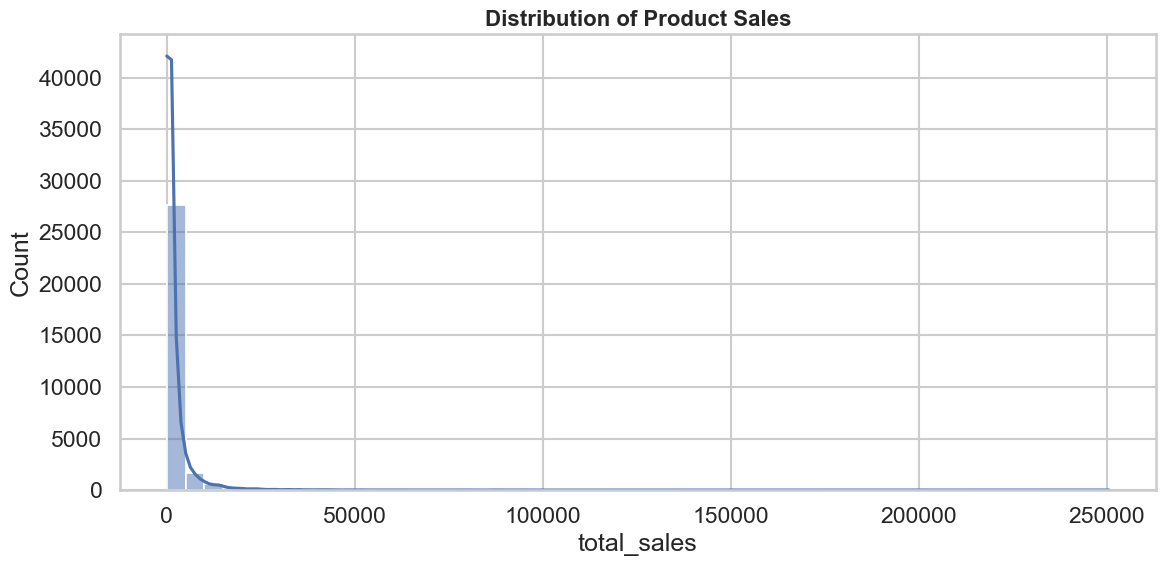

In [24]:
fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(
    sales['total_sales'],
    bins=50,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Product Sales")

plt.tight_layout()
plt.savefig(
    "../screenshots/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
import os

print(os.listdir("../screenshots"))

['category_distribution.png', 'sales_by_category.png', 'sales_by_state.png', 'sales_distribution.png', 'state_distribution.png', 'top_departments.png', 'top_products.png']


# Key Findings

1. California contains the largest number of product-store combinations.

2. FOODS is the dominant category in the dataset.

3. Product demand is highly skewed, with a small number of products
generating significantly higher sales than the majority.

4. Demand patterns vary across categories and states,
highlighting the importance of granular forecasting models.

5. These findings provide a strong foundation for feature engineering
and demand forecasting in the next phase of the project.

In [26]:
top_dept

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

### Key Insight

FOODS_3 is the largest department with 8,230 products,
significantly exceeding all other departments.

This suggests that food-related products dominate the retailer's
inventory and are likely major contributors to overall demand.

In [27]:
top_products

,item_id,total_sales
8412,FOODS_3_090,250502
18055,FOODS_3_586,192835
21104,FOODS_3_586,150122
8908,FOODS_3_586,134386
2314,FOODS_3_090,127203
29755,FOODS_3_090,121434
17559,FOODS_3_090,119496
20608,FOODS_3_090,114854
17721,FOODS_3_252,114153
15006,FOODS_3_586,112454


### Key Insight

The highest-selling products belong primarily to the FOODS_3 department.

A small group of products contributes disproportionately to total sales,
indicating a classic retail demand concentration pattern where a few
products drive a significant share of revenue.

In [28]:
category_sales

cat_id
FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
Name: total_sales, dtype: int64

### Key Insight

The FOODS category accounts for the majority of sales volume,
generating more than three times the demand of the HOUSEHOLD category.

This confirms that food products are the primary demand drivers
within the retail business.

In [29]:
state_sales

state_id
CA    28675547
TX    18899006
WI    18120856
Name: total_sales, dtype: int64

### Key Insight

California generates the highest sales volume among all states.

The demand gap between California and the other states suggests
regional differences in purchasing behavior, store density,
or product assortment.

### Create Daily Sales

In [32]:
daily_sales = sales.iloc[:, 6:].sum(axis=0).reset_index()

daily_sales.columns = ['d', 'sales']

daily_sales.head()

,d,sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


Merge with Calendar

In [33]:
daily_sales = daily_sales.merge(
    calendar[['d', 'date']],
    on='d',
    how='left'
)

daily_sales.head()

,d,sales,date
0,d_1,32631,2011-01-29
1,d_2,31749,2011-01-30
2,d_3,23783,2011-01-31
3,d_4,25412,2011-02-01
4,d_5,19146,2011-02-02


### Convert Data

In [35]:
daily_sales['date'] = pd.to_datetime(
    daily_sales['date']
)

### Plot Daily Demand Trend

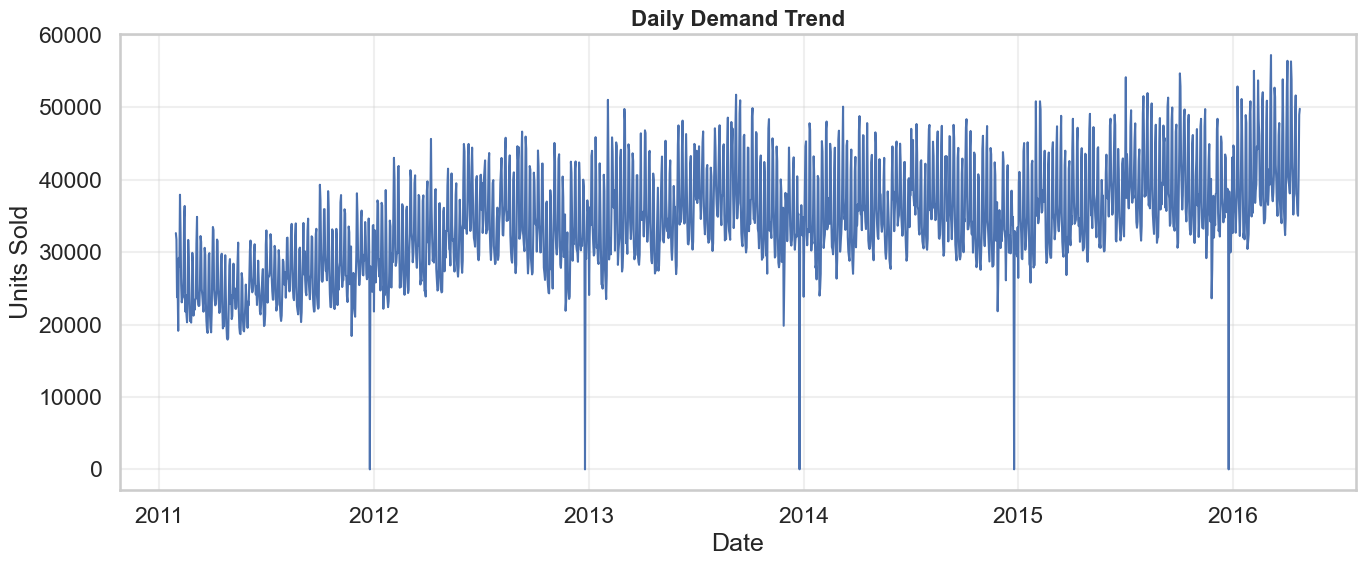

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    linewidth=1.5
)

plt.title(
    "Daily Demand Trend",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../screenshots/daily_demand_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
daily_sales = sales.iloc[:, 6:].sum(axis=0).reset_index()

daily_sales.columns = ['d', 'sales']

daily_sales = daily_sales.merge(
    calendar[['d','date']],
    on='d',
    how='left'
)

daily_sales.head()

,d,sales,date
0,d_1,32631,2011-01-29
1,d_2,31749,2011-01-30
2,d_3,23783,2011-01-31
3,d_4,25412,2011-02-01
4,d_5,19146,2011-02-02


In [38]:
daily_sales.shape

(1914, 3)

In [40]:
daily_sales['date'] = pd.to_datetime(
    daily_sales['date'],
    errors='coerce'
)

daily_sales['date'].isnull().sum()

1

In [41]:
daily_sales[daily_sales['date'].isnull()]

,d,sales,date
1913,total_sales,65695409,NaT


### Recreating daily_sales excluding total_sales

In [42]:
daily_columns = [col for col in sales.columns if col.startswith('d_')]

daily_sales = sales[daily_columns].sum(axis=0).reset_index()

daily_sales.columns = ['d', 'sales']

In [43]:
daily_sales = daily_sales.merge(
    calendar[['d', 'date']],
    on='d',
    how='left'
)

In [44]:
daily_sales['date'] = pd.to_datetime(
    daily_sales['date']
)

In [45]:
daily_sales['date'].isnull().sum()

0

In [46]:
daily_sales.head()

,d,sales,date
0,d_1,32631,2011-01-29
1,d_2,31749,2011-01-30
2,d_3,23783,2011-01-31
3,d_4,25412,2011-02-01
4,d_5,19146,2011-02-02


### Monthly Demand Trend

In [47]:
monthly_sales = (
    daily_sales
    .set_index('date')
    .resample('M')['sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

C:\Users\danis\AppData\Local\Temp\ipykernel_35988\587759426.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['sales']


,date,sales
0,2011-01-31,88163
1,2011-02-28,726375
2,2011-03-31,763567
3,2011-04-30,737713
4,2011-05-31,719562


### Weekday Seasonality

In [48]:
daily_sales['weekday'] = daily_sales['date'].dt.day_name()

weekday_sales = (
    daily_sales
    .groupby('weekday')['sales']
    .mean()
)

order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

weekday_sales = weekday_sales.reindex(order)

weekday_sales

weekday
Monday       32852.967033
Tuesday      30368.780220
Wednesday    30010.021978
Thursday     30205.007326
Friday       34225.985348
Saturday     41546.894161
Sunday       41130.021898
Name: sales, dtype: float64

### Year Wise Sales

In [50]:
daily_sales['year'] = daily_sales['date'].dt.year

year_sales = (
    daily_sales
    .groupby('year')['sales']
    .sum()
)

year_sales

year
2011     8856585
2012    12061837
2013    13135753
2014    13089776
2015    13800811
2016     4750647
Name: sales, dtype: int64

### Daily Demand Trend

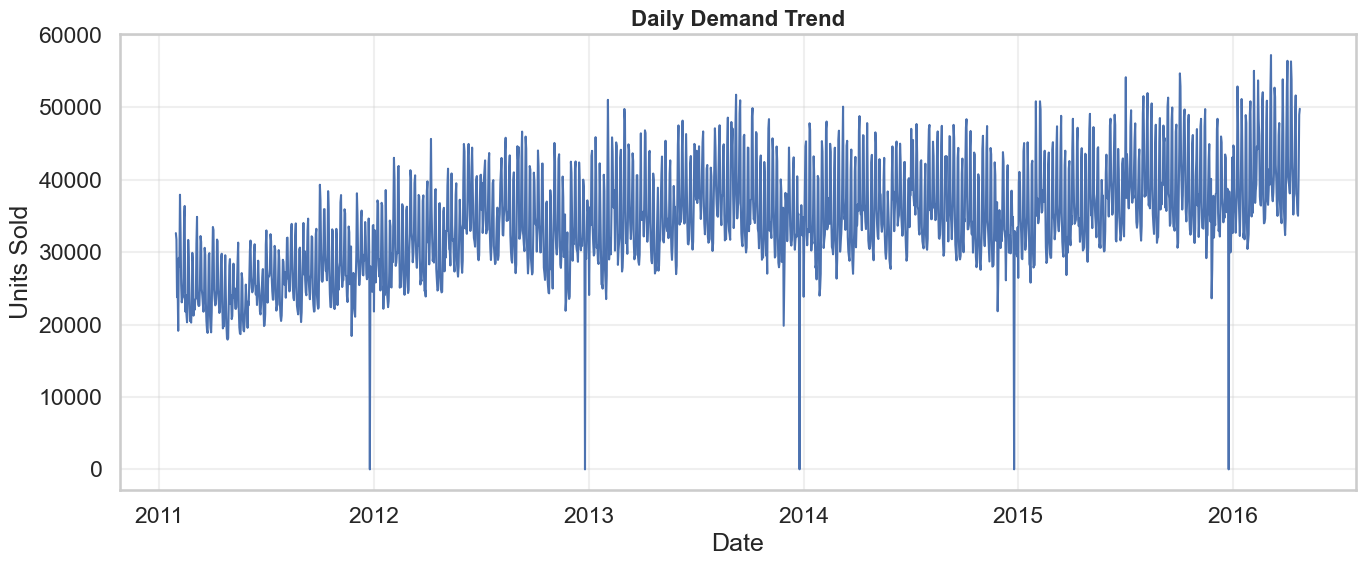

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    linewidth=1.5
)

plt.title(
    "Daily Demand Trend",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../screenshots/daily_demand_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
monthly_sales.head()

,date,sales
0,2011-01-31,88163
1,2011-02-28,726375
2,2011-03-31,763567
3,2011-04-30,737713
4,2011-05-31,719562


In [54]:
weekday_sales

weekday
Monday       32852.967033
Tuesday      30368.780220
Wednesday    30010.021978
Thursday     30205.007326
Friday       34225.985348
Saturday     41546.894161
Sunday       41130.021898
Name: sales, dtype: float64

### Weekday Seasonality Insight

Sales peak during weekends, particularly on Saturday and Sunday.

This indicates strong weekly seasonality and suggests that
day-of-week features may improve forecasting accuracy.

In [55]:
year_sales

year
2011     8856585
2012    12061837
2013    13135753
2014    13089776
2015    13800811
2016     4750647
Name: sales, dtype: int64

### Yearly Trend Insight

Sales exhibit a generally increasing trend from 2011 to 2015,
indicating business growth and expanding demand over time.

The lower sales observed in 2016 are due to partial-year data
availability rather than reduced customer demand.

### Holiday / Event Impact Analysis

In [56]:
event_days = calendar[
    calendar['event_type_1'].notna()
]

In [57]:
event_days[['date','event_name_1','event_type_1']].head()

,date,event_name_1,event_type_1
8,2011-02-06,SuperBowl,Sporting
16,2011-02-14,ValentinesDay,Cultural
23,2011-02-21,PresidentsDay,National
39,2011-03-09,LentStart,Religious
46,2011-03-16,LentWeek2,Religious


### Creat Even Flag

In [58]:
calendar['is_event'] = np.where(
    calendar['event_type_1'].notna(),
    1,
    0
)

calendar[['date','event_type_1','is_event']].head()

,date,event_type_1,is_event
0,2011-01-29,NaN,0
1,2011-01-30,NaN,0
2,2011-01-31,NaN,0
3,2011-02-01,NaN,0
4,2011-02-02,NaN,0


### Merge with Daily Sales

In [60]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [61]:
daily_sales['date'].dtype
calendar['date'].dtype

dtype('<M8[ns]')

In [62]:
event_analysis = daily_sales.merge(
    calendar[['date','is_event']],
    on='date',
    how='left'
)

event_analysis.head()

,d,sales,date,weekday,year,is_event
0,d_1,32631,2011-01-29,Saturday,2011,0
1,d_2,31749,2011-01-30,Sunday,2011,0
2,d_3,23783,2011-01-31,Monday,2011,0
3,d_4,25412,2011-02-01,Tuesday,2011,0
4,d_5,19146,2011-02-02,Wednesday,2011,0


In [63]:
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   d        1913 non-null   object        
 1   sales    1913 non-null   int64         
 2   date     1913 non-null   datetime64[ns]
 3   weekday  1913 non-null   object        
 4   year     1913 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(2)
memory usage: 67.4+ KB


In [64]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   object        
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   object        
 7   event_name_1  162 non-null    object        
 8   event_type_1  162 non-null    object        
 9   event_name_2  5 non-null      object        
 10  event_type_2  5 non-null      object        
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
 14  is_event      1969 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(

In [65]:
event_sales = (
    event_analysis
    .groupby('is_event')['sales']
    .mean()
)

event_sales

is_event
0    34489.207504
1    32655.149351
Name: sales, dtype: float64

In [75]:
event_type_sales = daily_sales.merge(
    calendar[['date','event_type_1']],
    on='date',
    how='left'
)

event_type_sales = event_type_sales[
    event_type_sales['event_type_1'].notna()
]

event_type_sales = (
    event_type_sales
    .groupby('event_type_1')['sales']
    .mean()
    .sort_values(ascending=False)
)

event_type_sales

event_type_1
Sporting     35796.062500
Cultural     34234.742857
Religious    33760.692308
National     29458.509804
Name: sales, dtype: float64

### Event Type Analysis

Sporting events generated the highest average sales among all event categories, indicating a stronger influence on customer purchasing behavior.

National events showed the lowest average sales, suggesting that not all events contribute equally to retail demand.

These findings indicate that event-type information can serve as a valuable feature for forecasting models.

### Compare Event vs Non-Event Days

In [67]:
event_sales = (
    event_analysis
    .groupby('is_event')['sales']
    .mean()
)

event_sales

is_event
0    34489.207504
1    32655.149351
Name: sales, dtype: float64

### Visualize

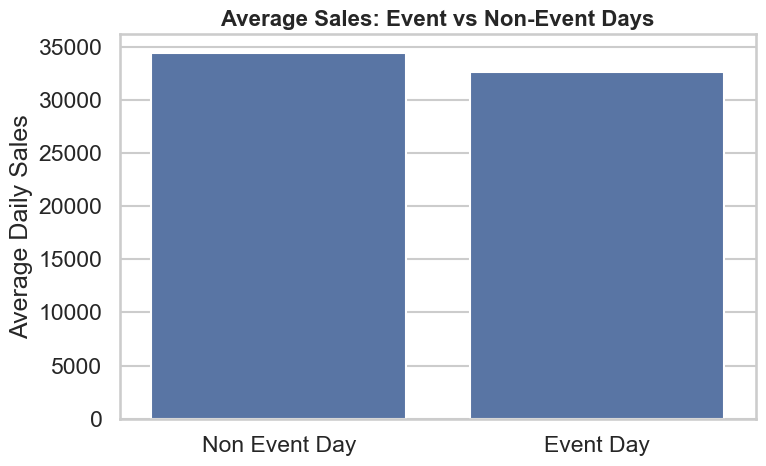

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=['Non Event Day','Event Day'],
    y=event_sales.values
)

plt.title(
    "Average Sales: Event vs Non-Event Days",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Average Daily Sales")

plt.tight_layout()

plt.savefig(
    "../screenshots/event_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Event Type Analysis

In [71]:
event_type_sales = daily_sales.merge(
    calendar[['date','event_type_1']],
    on='date',
    how='left'
)

In [72]:
event_type_sales = event_type_sales[
    event_type_sales['event_type_1'].notna()
]

In [73]:
event_type_sales = (
    event_type_sales
    .groupby('event_type_1')['sales']
    .mean()
    .sort_values(ascending=False)
)

event_type_sales

event_type_1
Sporting     35796.062500
Cultural     34234.742857
Religious    33760.692308
National     29458.509804
Name: sales, dtype: float64

### Visualize Event Types

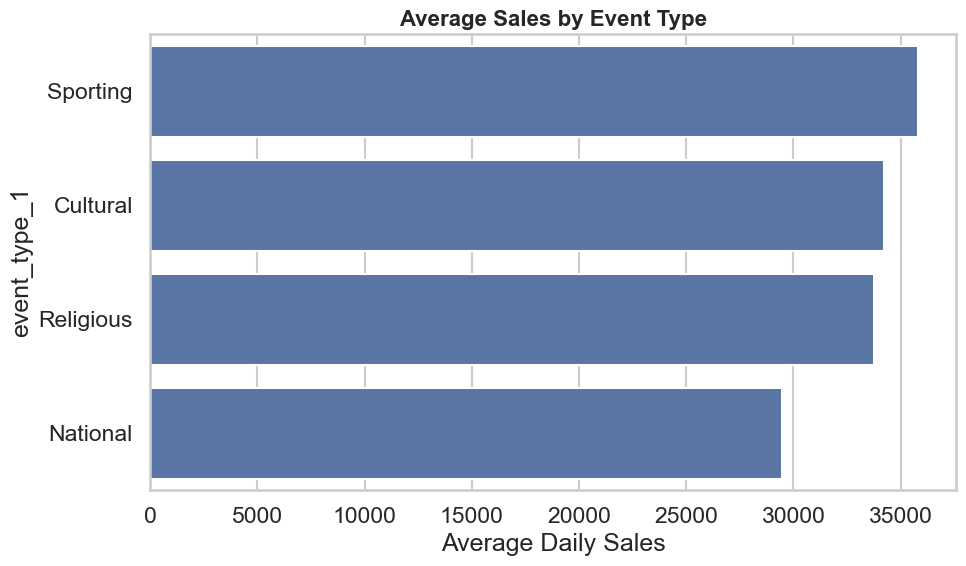

In [74]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=event_type_sales.values,
    y=event_type_sales.index
)

plt.title(
    "Average Sales by Event Type",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Daily Sales")

plt.tight_layout()

plt.savefig(
    "../screenshots/event_type_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()